# Paper-matched 4-PLD DNN training

This notebook follows the reference notebook's four PLDs `[1.525, 2.025, 2.525, 3.025]` seconds, dense noise-SD sampling, Rician `mc + ml` inputs, separate CBF/ATT networks, MAE loss, and 200-epoch early-stopped training.

In [1]:
import sys, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
project_root=Path.cwd().parent if not (Path.cwd()/'src').exists() else Path.cwd(); sys.path.insert(0,str(project_root/'src'))
from simulation import SimulationConfig, seed_everything, generate_dataset, select_inputs, reference_signal, RESULTS
cfg=SimulationConfig(); SEED=42; seed_everything(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device,'Reference PLDs:',cfg.plds_4_s,'LD:',cfg.tau_s,'Reference signal:',reference_signal(cfg))

Device: cuda Reference PLDs: (1.525, 2.025, 2.525, 3.025) LD: 1.8 Reference signal: 334.20389639412525


In [2]:
N_TRAIN,N_VAL=4000,1000
X_train_full,Y_train,_=generate_dataset(N_TRAIN,cfg,SEED+10,snr=10.0); X_val_full,Y_val,_=generate_dataset(N_VAL,cfg,SEED+20,snr=10.0)
X_train=select_inputs(X_train_full,cfg,'4_pld'); X_val=select_inputs(X_val_full,cfg,'4_pld')
X_mean=X_train.mean(0,keepdims=True).astype('float32'); X_std=X_train.std(0,keepdims=True).astype('float32')+1e-8
X_train=((X_train-X_mean)/X_std).astype('float32'); X_val=((X_val-X_mean)/X_std).astype('float32')
CBF_mean,CBF_std=float(Y_train[:,0].mean()),float(Y_train[:,0].std()+1e-8); ATT_mean,ATT_std=float(Y_train[:,1].mean()),float(Y_train[:,1].std()+1e-8)
print('Train:',X_train.shape,Y_train.shape,'Validation:',X_val.shape,Y_val.shape); print('CBF/ATT ranges:',(Y_train[:,0].min(),Y_train[:,0].max()),(Y_train[:,1].min(),Y_train[:,1].max()))

Train: (4000, 4) (4000, 2) Validation: (1000, 4) (1000, 2)
CBF/ATT ranges: (np.float32(0.0071000634), np.float32(99.87163)) (np.float32(0.5003694), np.float32(2.9997208))


In [3]:
class StandardizedNet(nn.Module):
    def __init__(self,input_dim,width):
        super().__init__(); layers=[nn.Linear(input_dim,width),nn.ELU()]
        for _ in range(8): layers += [nn.Linear(width,width),nn.ELU()]
        layers.append(nn.Linear(width,1)); self.backbone=nn.Sequential(*layers)
        for layer in self.backbone:
            if isinstance(layer,nn.Linear): nn.init.kaiming_normal_(layer.weight,nonlinearity='relu'); nn.init.zeros_(layer.bias)
    def forward(self,x): return self.backbone(x)
def train_net(net,x_train,y_train,x_val,y_val,mean,std,name):
    yt=((y_train-mean)/std).astype('float32'); yv=((y_val-mean)/std).astype('float32'); tr=DataLoader(TensorDataset(torch.from_numpy(x_train),torch.from_numpy(yt[:,None])),batch_size=512,shuffle=True); va=DataLoader(TensorDataset(torch.from_numpy(x_val),torch.from_numpy(yv[:,None])),batch_size=512)
    opt=torch.optim.Adam(net.parameters(),lr=1e-3); loss_fn=nn.L1Loss(); best=float('inf'); state=copy.deepcopy(net.state_dict()); stale=0; rows=[]
    for epoch in range(1,201):
        net.train(); train_loss=0
        for xb,yb in tr:
            opt.zero_grad(); loss=loss_fn(net(xb.to(device)),yb.to(device)); loss.backward(); torch.nn.utils.clip_grad_norm_(net.parameters(),1.0); opt.step(); train_loss+=loss.item()
        net.eval(); val_loss=sum(loss_fn(net(xb.to(device)),yb.to(device)).item() for xb,yb in va)/len(va); train_loss/=len(tr); rows.append({'epoch':epoch,'train_mae':train_loss,'validation_mae':val_loss}); print(f'{name} epoch {epoch:03d}/200 train={train_loss:.6f} val={val_loss:.6f}')
        if val_loss<best: best=val_loss; state=copy.deepcopy(net.state_dict()); stale=0
        else:
            stale+=1
            if stale>=20: print(name,'early stopped at',epoch); break
    net.load_state_dict(state); return pd.DataFrame(rows)
CBFnet=StandardizedNet(4,50).to(device); ATTnet=StandardizedNet(4,100).to(device)
CBF_history=train_net(CBFnet,X_train,Y_train[:,0],X_val,Y_val[:,0],CBF_mean,CBF_std,'CBF-4PLD'); ATT_history=train_net(ATTnet,X_train,Y_train[:,1],X_val,Y_val[:,1],ATT_mean,ATT_std,'ATT-4PLD')
display(CBF_history.tail()); display(ATT_history.tail())

CBF-4PLD epoch 001/200 train=0.701526 val=0.289164
CBF-4PLD epoch 002/200 train=0.284542 val=0.279383
CBF-4PLD epoch 003/200 train=0.237091 val=0.191905
CBF-4PLD epoch 004/200 train=0.177572 val=0.160458
CBF-4PLD epoch 005/200 train=0.154780 val=0.154763
CBF-4PLD epoch 006/200 train=0.160157 val=0.165064
CBF-4PLD epoch 007/200 train=0.159578 val=0.154313
CBF-4PLD epoch 008/200 train=0.141801 val=0.158598
CBF-4PLD epoch 009/200 train=0.141442 val=0.141283
CBF-4PLD epoch 010/200 train=0.148781 val=0.158761
CBF-4PLD epoch 011/200 train=0.158327 val=0.155596
CBF-4PLD epoch 012/200 train=0.144011 val=0.146156
CBF-4PLD epoch 013/200 train=0.140349 val=0.142484
CBF-4PLD epoch 014/200 train=0.133684 val=0.141998
CBF-4PLD epoch 015/200 train=0.135903 val=0.131438
CBF-4PLD epoch 016/200 train=0.134335 val=0.131551
CBF-4PLD epoch 017/200 train=0.131391 val=0.131668
CBF-4PLD epoch 018/200 train=0.130519 val=0.135018
CBF-4PLD epoch 019/200 train=0.132259 val=0.126228
CBF-4PLD epoch 020/200 train=0.

,epoch,train_mae,validation_mae
34,35,0.130512,0.134338
35,36,0.134782,0.146111
36,37,0.132521,0.132924
37,38,0.123397,0.131180
38,39,0.132942,0.154784


,epoch,train_mae,validation_mae
88,89,0.318882,0.350040
89,90,0.319887,0.364795
90,91,0.329557,0.368328
91,92,0.332566,0.351852
92,93,0.324372,0.354909


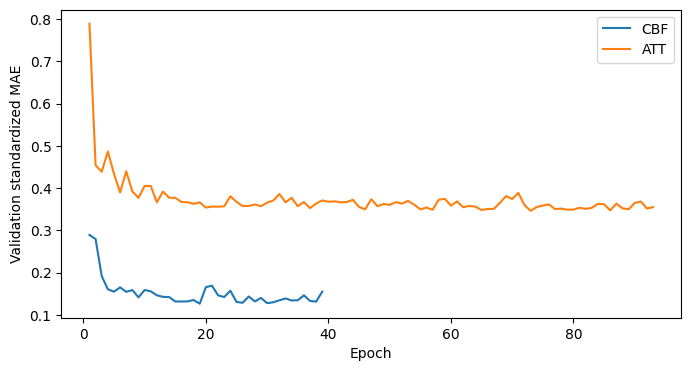

Saved: D:\fiinal year project\dnn_pld_reduction\results\model_4_pld


In [4]:
output_dir=RESULTS/'model_4_pld'; output_dir.mkdir(parents=True,exist_ok=True)
torch.save(CBFnet.state_dict(),output_dir/'cbf_model.pt'); torch.save(ATTnet.state_dict(),output_dir/'att_model.pt')
CBF_history.to_csv(output_dir/'cbf_training_history.csv',index=False); ATT_history.to_csv(output_dir/'att_training_history.csv',index=False)
np.savez(output_dir/'normalization.npz',X_mean=X_mean,X_std=X_std,CBF_mean=CBF_mean,CBF_std=CBF_std,ATT_mean=ATT_mean,ATT_std=ATT_std)
(output_dir/'config.json').write_text(json.dumps({'input_dim':4,'plds_s':list(cfg.plds_4_s),'max_epochs':200,'patience':20,'loss':'MAE','noise':'dense SD Rician mc+ml'},indent=2),encoding='utf-8')
plt.figure(figsize=(8,4)); plt.plot(CBF_history.epoch,CBF_history.validation_mae,label='CBF'); plt.plot(ATT_history.epoch,ATT_history.validation_mae,label='ATT'); plt.xlabel('Epoch'); plt.ylabel('Validation standardized MAE'); plt.legend(); plt.show(); print('Saved:',output_dir)